<br>

# Case study: FAO multiplex
## Distance matrices, RBO, and clustering analysis

<br>

<br>

<span style="font-size:1.15em;">

* [1. The FAO dataset](#chapter1)
    * [1.1 Data loading](#section_1_1)
    * [1.2 Graphs creation and partitions](#section_1_2)
    
<br>    

* [2. Distance matrices](#chapter2)

<br>    
    
* [3. Spearman correlation and rank-biased overlap](#chapter3)
    
<br>
    
* [4. Hierarchical clustering](#chapter4)
    * [4.1 Normalized information score](#section_4_1)
    * [4.2 Clusters against linkage distance](#section_4_2)
    
<br>
    
* [Appendix](#chapter5)

</span>
    
<br>

In [1]:
from functions_fao import * # Import the NMI measures, Jensen-Shannon distance, and some utilities (NumPy, etc)
import rbo                  # install it via !pip install rbo 

# Plot settings
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'text.usetex': True}) # LaTeX capabilities 
matplotlib.rcParams.update({'text.latex.preamble': r"", "font.serif": "Times"})
matplotlib.rcParams.update({'font.family':'serif'})
get_ipython().run_line_magic('matplotlib', 'inline')
get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'svg' # render figures in SVG")
# matplotlib.rcdefaults() # reset matplotlib


<br>

<br>

## 1. The FAO dataset <a class="anchor" id="chapter1"></a>

### 1.1 Data loading <a class="anchor" id="section_1_1"></a>

<br>

Let us load the edge list contained in `edges.csv` as a DataFrame `df_links`.

In [2]:
# Edges dataset
names = ['source', 'target', 'weight', 'layer']
df_links = pd.read_csv('edges.csv', sep=',', comment='#', header=None, names=names)
df_links

,source,target,weight,layer
0,0,1,6,3
1,0,13,14,3
2,0,27,1,3
3,0,43,13,3
4,0,44,3,3
...,...,...,...,...
318341,212,16,28,359
318342,212,34,51,359
318343,212,39,295,359
318344,212,21,8,362


The DataFrame above specifies the direction, weight, and the layer of an edge. We thus create below a dictionary containing NetworkX objects (graphs) associated with each layer found in `df_link`. Due to inconsistencies within another dataset (the GDP statistics from the World Bank dataset, see below), it was necessary to remove the following 13 nodes (countries):

```
8	China,_mainland	
9	China,_Taiwan_Province_of	
92	Unspecified	
110	Sudan_(former)	
128	Netherlands_Antilles	
173	Falkland_Islands_(Malvinas)
185	Occupied_Palestinian_Territory	
190	Cook_Islands	
194	Niue	
198	Montserrat	
199	Saint_Pierre_and_Miquelon	
207	Saint_Helena,_Ascension_and_Tristan_da_Cunha	
210	Mayotte
213	Andorra

```

<br>

<br>

### 1.2 Graphs creation and partition <a class="anchor" id="section_1_2"></a>

<br>

In [3]:
# Placeholder for dictionary of graphs
layer_graphs = {}
unique_layers = df_links['layer'].unique()

# Graph creation
num_nodes = df_links['source'].max()
indices_to_remove = [8,9,92,110,128,140,142,155,173,175,185,187,190,194,198,199,200,207,210,213] # problematic countries

for layer in unique_layers:
    layer_edges = df_links[df_links['layer'] == layer][['source', 'target', 'weight']].values
    layer_graph = nx.Graph()
    layer_graph.add_nodes_from(range(num_nodes))
    layer_graph.add_weighted_edges_from(layer_edges)
    layer_graph.remove_nodes_from(indices_to_remove) # remove problematic countries
    layer_graph.remove_edges_from([(u, v) for u, v in layer_graph.edges() if u == v]) # remove self-edges
    layer_graphs[layer] = layer_graph

<br>

Having created and stored the graphs in `layer_graphs`, we can straightforwardly compute the $\text{NMI}$, $\text{DC-NMI}$, and the Jensen-Shannon distance $D_{\text{JS}}$ between them. However, to obtain the analogous mesoscale measure via the $\text{MesoNMI}(B)$ function, we need to build a partition given by a group membership vector $\textbf{b}=(b_1,\dots,b_N)$, where $b_i\leq B$ specifies the group of the $i$-th node. Here, we create partitions for:

<br>

(1) World hemispheres according to the socioeconomic labels of "Global North" and "Global South" ($B=2$);

(2) World continents ($B=6$); 

(3) GDP of countries ranked into 50 divisions ($B=50$).

<br>

The file `df_partition.py` contains the script to generate all the three partitions mentioned above. In what follows, we simply load its output (the CSV file `df_partition.csv`).

In [4]:
names=["index","name","hemisphere","continent","gdp_2010","b_hemis","b_cont","b_gdp"]
df_partition=pd.read_csv("df_partition.csv", sep=',', comment=None, header=0, names=names)
df_partition

,index,name,hemisphere,continent,gdp_2010,b_hemis,b_cont,b_gdp
0,0,Afghanistan,South,Asia,14.362441,0,1,34
1,1,Australia,North,Oceania,2.226538,1,4,16
2,2,Austria,North,Europe,1.837094,1,2,15
3,3,Belgium,North,Europe,2.864293,1,2,17
4,4,Brazil,South,South America,7.528226,0,5,24
...,...,...,...,...,...,...,...,...
190,208,Tuvalu,North,Oceania,-2.222222,1,4,9
191,209,Cayman_Islands,South,South America,-2.715635,0,5,9
192,211,Maldives,South,Asia,6.835471,0,1,23
193,212,Mauritania,South,Africa,2.620230,0,0,16


Finally, the group membership vectors (partitions) are obtained as Numpy arrays (the `[:-1]` is to "ad hocly" remove Andorra).

In [5]:
b_hemis = df_partition.b_hemis.to_numpy()[:-1]
b_cont  = df_partition.b_cont.to_numpy()[:-1]
b_gdp   = df_partition.b_gdp.to_numpy()[:-1]

<br>

<br>

<br>

<br>

## 2. Distance matrices <a class="anchor" id="chapter2"></a>

<br>

The code to compute the distance matrices (NMI, DC-NMI, MesoNMI, and Jensen-Shannon) can be found in the [Appendix](#chapter4). We do not recommend run it because it takes a few hours to finish. Hence, in the next cell we simply load them as Numpy arrays (their names should be self-explanatory).

In [6]:
M_nmi = np.load("matrix_nmi.npy")
M_dcnmi = np.load("matrix_dcnmi.npy")
M_meso_hemis = np.load("matrix_meso_hemisphere_b2.npy")
M_meso_cont = np.load("matrix_meso_continent_b6.npy")
M_meso_gdp = np.load("matrix_meso_gdp_b50.npy")
M_max = np.load("matrix_meso_bmax.npy")
M_manlio = np.load("matrix_manlio.npy")
M_manlio = np.ones((len(M_manlio),len(M_manlio)))-M_manlio # matrix (1 - D_JS) to better compare w/ others

Below we plot the six distance matrices of interest.

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(10,5))
fig.tight_layout()
fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(hspace=0.75)

# nmi
im1 = axs[0, 0].imshow(M_nmi, cmap='viridis', interpolation='none')
axs[0, 0].set_title('NMI', fontsize=12, pad=10)
fig.colorbar(im1, ax=axs[0, 0])

# dc-nmi
im2 = axs[0, 1].imshow(M_dcnmi, cmap='viridis', interpolation='none')
axs[0, 1].set_title('DC-NMI', fontsize=12, pad=10)
fig.colorbar(im2, ax=axs[0, 1])

# meso B=2
im3 = axs[0, 2].imshow(M_meso_hemis, cmap='viridis', interpolation='none')
axs[0, 2].set_title('MesoNMI \n(hemispheres, $B=2$)', fontsize=12, pad=10)
fig.colorbar(im3, ax=axs[0, 2])

# meso B=6
im4 = axs[1, 0].imshow(M_meso_cont, cmap='viridis', interpolation='none')
axs[1, 0].set_title('MesoNMI \n(continents, $B=6$)', fontsize=12, pad=10)
fig.colorbar(im4, ax=axs[1, 0])

# meso B=50
im5 = axs[1, 1].imshow(M_meso_gdp, cmap='viridis', interpolation='none')
axs[1, 1].set_title('MesoNMI \n(ranked-GDP, $B=50$)', fontsize=12, pad=10)
fig.colorbar(im5, ax=axs[1, 1])

# jensen-shannon
im6 = axs[1, 2].imshow(M_manlio, cmap='viridis', interpolation='none')
axs[1, 2].set_title('Jensen-Shannon distance \n$(1-D_{\\textrm{JS}})$', fontsize=12, pad=10)
fig.colorbar(im6, ax=axs[1,2])

for i in range(2):
    for j in range(3):
        axs[i,j].set_xticks([0, 363])
        axs[i,j].set_xticklabels([1, 364], fontsize=12, rotation=0)
        axs[i,j].set_yticks([0, 363])
        axs[i,j].set_yticklabels([1, 364], fontsize=12, rotation=0)
        axs[i,j].set_xlabel('Layer', fontsize=12, labelpad=-5)
        axs[i,j].set_ylabel('Layer', fontsize=12, labelpad=-10);

<br>

<br>

## Spearman correlation and rank-biased overlap <a class="anchor" id="chapter3"></a>

<br>

Here we compute two 6x6 matrices comparing the six different methods of measuring similarity (distances) between graphs. The first is the common Spearman rank correlation, while the second is known as the rank-biased overlap (RBO). In RBO, we take into account the weights of the ranked elements in a list. The procedure can be summarized a follows: given a vector $\textbf{v}=[v_1, v_2, \dots, v_N]$, we assign to $\textbf{v}$ an index vector $I_{\textbf{v}}=[1, 2, \dots, N]$ to obtain its ranked version 

$$\text{rank}(I_{\textbf{v}})=[i, j, \dots, k] ~,$$

where $i>j>\dots>k$. The similarity between two vectors $\textbf{v}$ and $\textbf{u}$ is thus based on the set-theoretic intersection between their ranked versions $\text{rank}(I_{\textbf{v}})$ and $\text{rank}(I_{\textbf{u}})$, respectively.

Let us compute the Spearman correlation between distance matrices, as well as their RBO.

In [8]:
from scipy.stats import spearmanr

X = [M_nmi, M_dcnmi, M_meso_hemis, M_meso_cont, M_meso_gdp, M_max, M_manlio]
X_flattened = [x.flatten() for x in X] # flatten to get vectors

n=len(X)
P_spearman=np.zeros((n,n))
for i in range(len(X)):
    for j in range(i, len(X)):
        P_spearman[i,j], _ = spearmanr(X_flattened[i], X_flattened[j])
        P_spearman[j,i]    = P_spearman[i,j]

P_rbo=np.zeros((n,n))
for i in range(len(X)):
    for j in range(i, len(X)):
        Xi,Xj = X_flattened[i], X_flattened[j]
        Xi,Xj = sorted(np.arange(len(Xi)), key=lambda i: Xi[i], reverse=True), sorted(np.arange(len(Xj)), key=lambda i: Xj[i], reverse=True)
        P_rbo[i,j] = rbo.RankingSimilarity(Xi, Xj).rbo()
        P_rbo[j,i] = P_rbo[i,j]

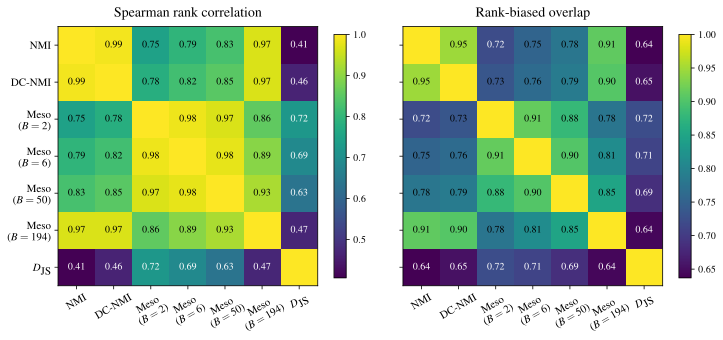

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12,8))
fig.subplots_adjust(wspace=0.0625)

# Plot 1: Spearman rank correlation
im1 = axs[0].imshow(P_spearman, cmap='viridis', interpolation='none')
axs[0].set_title('Spearman rank correlation', fontsize=14, pad=10)
axs[0].set_xticks(ticks=[0, 1, 2, 3, 4, 5, 6])
axs[0].set_xticklabels(['NMI', 'DC-NMI', 'Meso \n($B=2$)', 'Meso \n($B=6$)', 'Meso \n($B=50$)', 'Meso \n($B=194$)', '$D_{\\textrm{JS}}$'], rotation=30, fontsize=11)
axs[0].set_yticks(ticks=[0, 1, 2, 3, 4, 5, 6])
axs[0].set_yticklabels(['NMI', 'DC-NMI', 'Meso \n($B=2$)', 'Meso \n($B=6$)', 'Meso \n($B=50$)', 'Meso \n($B=194$)', '$D_{\\textrm{JS}}$'], fontsize=11)
for i in range(len(P_spearman)):
    for j in range(len(P_spearman[0])):
        if i != j:
            text_color = 'black' if np.mean(plt.cm.viridis(P_spearman[i, j])[:3]) > 0.5 else 'white'
            axs[0].text(j, i, f'{P_spearman[i, j]:.2f}', ha='center', va='center', color=text_color)
# axs[0].colorbar()
fig.colorbar(im1, ax=axs[0], shrink=0.55)

# Plot 2: Rank-biased overlap
im2 = axs[1].imshow(P_rbo, cmap='viridis', interpolation='none')
# axs[1].imshow(P_rbo, cmap='viridis', interpolation='none')
axs[1].set_title('Rank-biased overlap', fontsize=14, pad=10)
axs[1].set_xticks(ticks=[0, 1, 2, 3, 4, 5, 6])
axs[1].set_xticklabels(['NMI', 'DC-NMI', 'Meso \n($B=2$)', 'Meso \n($B=6$)', 'Meso \n($B=50$)', 'Meso \n($B=194$)', '$D_{\\textrm{JS}}$'], rotation=30, fontsize=11)
axs[1].set_yticks(ticks=[0, 1, 2, 3, 4, 5, 6])
axs[1].set_yticklabels([], fontsize=11)
for i in range(len(P_rbo)):
    for j in range(len(P_rbo[0])):
        if i != j:
            text_color = 'black' if np.mean(plt.cm.viridis(P_rbo[i, j])[:3]) > 0.5 else 'white'
            axs[1].text(j, i, f'{P_rbo[i, j]:.2f}', ha='center', va='center', color=text_color)
# axs[1].colorbar()
fig.colorbar(im2, ax=axs[1], shrink=0.55);

<br>

<br>

<br>

<br>

## Hierarchical clustering analysis <a class="anchor" id="chapter4"></a>

<br>

### Normalized mutual information score <a class="anchor" id="section_4_1"></a>

Here we perform hierarchical clustering analysis over the distance matrices obtained previously. In the plot below, the heatmaps show the normalized mutual information score for clustering results coming from two different methods (say, NMI and DC-NMI). On the left side, we consider dendograms that are cut at two total clusters, whereas the right side the number of clusters is ten.

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.cluster import normalized_mutual_info_score

X = [M_nmi, M_dcnmi, M_meso_hemis, M_meso_cont, M_meso_gdp, M_manlio] 
n=len(X)
P_clust_2=np.ones((n,n))
for i in range(len(X)):
    for j in range(i, len(X)):
        model_x, model_y = AgglomerativeClustering(linkage='ward', n_clusters=2), AgglomerativeClustering(linkage='ward', n_clusters=2)
        labels_x, labels_y = model_x.fit_predict(X[i]), model_x.fit_predict(X[j])
        P_clust_2[i,j]=normalized_mutual_info_score(labels_x, labels_y)
        P_clust_2[j,i]=P_clust_2[i,j]
        
P_clust_10=np.ones((n,n))
for i in range(len(X)):
    for j in range(i, len(X)):
        model_x, model_y = AgglomerativeClustering(linkage='ward', n_clusters=10), AgglomerativeClustering(linkage='ward', n_clusters=10)
        labels_x, labels_y = model_x.fit_predict(X[i]), model_x.fit_predict(X[j])
        P_clust_10[i,j]=normalized_mutual_info_score(labels_x, labels_y)
        P_clust_10[j,i]=P_clust_10[i,j]

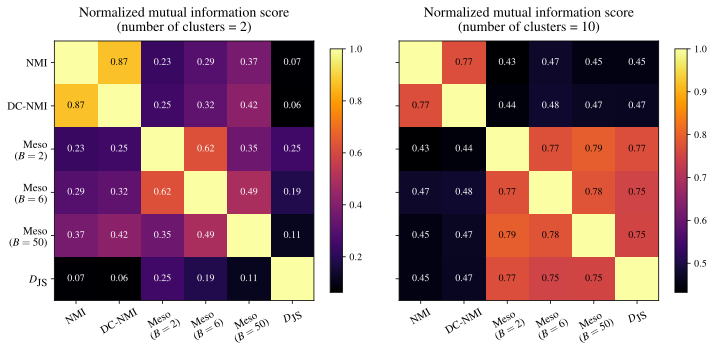

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12,8))
fig.subplots_adjust(wspace=0.0625)

# Plot 1: nmi score n_clusters=2
im1 = axs[0].imshow(P_clust_2, cmap='inferno', interpolation='none')
axs[0].set_title('Normalized mutual information score \n (number of clusters = 2)', fontsize=14, pad=10)
axs[0].set_xticks(ticks=[0, 1, 2, 3, 4, 5])
axs[0].set_xticklabels(['NMI', 'DC-NMI', 'Meso \n($B=2$)', 'Meso \n($B=6$)', 'Meso \n($B=50$)', '$D_{\\textrm{JS}}$'], rotation=30, fontsize=11)
axs[0].set_yticks(ticks=[0, 1, 2, 3, 4, 5])
axs[0].set_yticklabels(['NMI', 'DC-NMI', 'Meso \n($B=2$)', 'Meso \n($B=6$)', 'Meso \n($B=50$)', '$D_{\\textrm{JS}}$'], fontsize=11)
for i in range(len(P_clust_2)):
    for j in range(len(P_clust_2[0])):
        if i != j:
            text_color = 'black' if np.mean(plt.cm.viridis(P_clust_2[i, j])[:3]) > 0.5 else 'white'
            axs[0].text(j, i, f'{P_clust_2[i, j]:.2f}', ha='center', va='center', color=text_color)
fig.colorbar(im1, ax=axs[0], shrink=0.55)

# Plot 2: nmi score n_clusters=2
im2 = axs[1].imshow(P_clust_10, cmap='inferno', interpolation='none')
axs[1].set_title('Normalized mutual information score \n (number of clusters = 10)', fontsize=14, pad=10)
axs[1].set_xticks(ticks=[0, 1, 2, 3, 4, 5])
axs[1].set_xticklabels(['NMI', 'DC-NMI', 'Meso \n($B=2$)', 'Meso \n($B=6$)', 'Meso \n($B=50$)', '$D_{\\textrm{JS}}$'], rotation=30, fontsize=11)
axs[1].set_yticks(ticks=[0, 1, 2, 3, 4, 5])
axs[1].set_yticklabels([], fontsize=11)
for i in range(len(P_clust_10)):
    for j in range(len(P_clust_10[0])):
        if i != j:
            text_color = 'black' if np.mean(plt.cm.viridis(P_clust_10[i, j])[:3]) > 0.5 else 'white'
            axs[1].text(j, i, f'{P_clust_10[i, j]:.2f}', ha='center', va='center', color=text_color)

fig.colorbar(im2, ax=axs[1], shrink=0.55);

<br>

<br>

### Clusters against linkage distance <a class="anchor" id="section_4_2"></a>

<br>

In the plot below, we compute the linkage distance at every cut of dendogram from 2 to 20 clusters.

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

X = [M_nmi, M_dcnmi, M_meso_hemis, M_meso_cont, M_meso_gdp, M_manlio]

# placeholder for linkage distances and number of clusters
linkage_distances_list = []
num_clusters_list = []

for M in X:
    Z = linkage(M, method='ward')
    linkage_distances = []
    num_clusters = []
    for k in range(2, 21): 
        dendro = dendrogram(Z, truncate_mode='lastp', p=k, no_plot=True) # cut dendogram at k clusters
        linkage_distance = dendro['dcoord'][0][1]
        linkage_distances.append(linkage_distance)
        num_clusters.append(k)
    linkage_distances_list.append(linkage_distances)
    num_clusters_list.append(num_clusters)

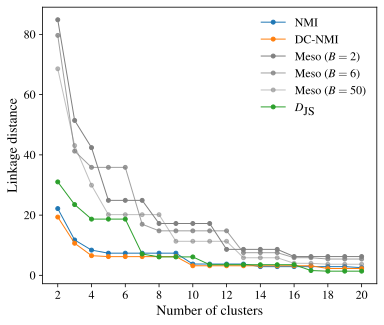

In [14]:
fig, ax = plt.subplots(1,1, figsize=(6,5))

X_names=['NMI', 'DC-NMI', 'Meso ($B=2$)', 'Meso ($B=6$)', 'Meso ($B=50$)', '$D_{\\textrm{JS}}$']
grays=[_, _, 1.00, 0.75, 0.50]

for i, (linkage_distances, num_clusters) in enumerate(zip(linkage_distances_list, num_clusters_list)):
    label = X_names[i]
    if i in [2,3,4]:
        ax.plot(num_clusters, linkage_distances, marker='o', markersize=4, ls='-', lw=1, label=label, 
                color='gray', alpha=grays[i])
    else:
        ax.plot(num_clusters, linkage_distances, marker='o', markersize=4, ls='-', lw=1, label=label)

ax.set_xlabel('Number of clusters', fontsize=14)
ax.set_ylabel('Linkage distance', fontsize=14)

ax.set_xticks(ticks=np.arange(2,21,2))
ax.set_xticklabels(np.arange(2,21,2), fontsize=12)

ax.set_yticks(ticks=np.arange(0, 100, 20))
ax.set_yticklabels(np.arange(0, 100, 20), fontsize=12)



ax.legend(frameon=False, fontsize=12);

<br>

<br>

<br>

<br>

<br>

<br>

<br>

<br>

## Appendix

<br>

For completeness, we put here the code to compute the distance matrices. (There's an intentional syntax error so as to not accidentally run this cell, since it takes a few hours to finish.)

In [15]:
print("This cell take hours to finalize. Run with conscience"

n=layer_graphs[1].number_of_nodes()
N=len(layer_graphs)

# nmi
M=np.zeros((N,N))
for i in range(1, N+1):
    for j in range(i, N+1):
        M[i-1,j-1]=graphNMI(set(layer_graphs[i].edges()),set(layer_graphs[j].edges()),n)
        M[j-1,i-1]=M[i-1,j-1]
        M[i-1,i-1]=1
np.save('matrix_nmi.npy', M)

# dc=nmi
M=np.zeros((N,N))
for i in range(1, N+1):
    for j in range(i, N+1):
        gi,gj=nx.convert_node_labels_to_integers(layer_graphs[i], first_label=0),nx.convert_node_labels_to_integers(layer_graphs[j], first_label=0)
        M[i-1,j-1]=graphDCNMI(set(gi.edges()),set(gj.edges()),n)
        M[j-1,i-1]=M[i-1,j-1]
        M[i-1,i-1]=1
np.save('matrix_dcnmi.npy', M)

# meso B=2 (hemisphere)
M=np.zeros((N,N))
for i in range(1, N+1):
    for j in range(i, N+1):
        gi,gj=nx.convert_node_labels_to_integers(layer_graphs[i], first_label=0),nx.convert_node_labels_to_integers(layer_graphs[j], first_label=0)
        M[i-1,j-1]=mesoNMI(set(gi.edges()),set(gj.edges()),b_hemis)
        M[j-1,i-1]=M[i-1,j-1]
        M[i-1,i-1]=1
np.save('matrix_meso_hemisphere_b2.npy', M)

# meso B=6 (continent)
M=np.zeros((N,N))
for i in range(1, N+1):
    for j in range(i, N+1):
        gi,gj=nx.convert_node_labels_to_integers(layer_graphs[i], first_label=0),nx.convert_node_labels_to_integers(layer_graphs[j], first_label=0)
        M[i-1,j-1]=mesoNMI(set(gi.edges()),set(gj.edges()),b_cont)
        M[j-1,i-1]=M[i-1,j-1]
        M[i-1,i-1]=1
np.save('matrix_meso_continent_b6.npy', M)

# meso B=50 (gdp)
M=np.zeros((N,N))
for i in range(1, N+1):
    for j in range(i, N+1):
        gi,gj=nx.convert_node_labels_to_integers(layer_graphs[i], first_label=0),nx.convert_node_labels_to_integers(layer_graphs[j], first_label=0)
        M[i-1,j-1]=mesoNMI(set(gi.edges()),set(gj.edges()),b_gdp)
        M[j-1,i-1]=M[i-1,j-1]
        M[i-1,i-1]=1
np.save('matrix_meso_gdp_b50.npy', M)

# jensen-shannon
N=len(layer_graphs)
M=np.zeros((N,N))
for i in range(1, N+1):
    for j in range(i, N+1):
        M[i-1,j-1]=d_jensen_shannon(layer_graphs[i],layer_graphs[j])
        M[j-1,i-1]=M[i-1,j-1]
        M[i-1,i-1]=0
np.save('matrix_manlio.npy', M)

SyntaxError: '(' was never closed (1914318408.py, line 1)

<br>

<br>

<br>
<br>

<br>

<br>
<br>

<br>

<br>
<br>

<br>

<br>
<br>

<br>

<br>
